# Feature embedding (PCA / UMAP)

Turns the raw PSM features that feed the `grove_forest_new_features` isolation-forest ensemble (`../model/SUOD_model.pkl`, trained on the 7 features in `../iforest_config.yaml`) directly into a 2D embedding, plus a richer variant that adds the direction-aware pairwise rotations from `train_direction_aware_iforest.py` (`spectral_angle` vs `fraction_observed` / `fraction_observed_and_predicted`).

Companion notebook: [isoforest_leaf_embedding_pca_umap.ipynb](isoforest_leaf_embedding_pca_umap.ipynb) builds an embedding from the *trained forest's* leaf structure instead, on the same PSM sample.

In [94]:
import sys
sys.path.insert(0, '.')

import matplotlib.pyplot as plt
import numpy as np
import umap
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from _shared import (
    FEATURES, compute_training_cutoff, load_psm_sample, local_disagreement_correction,
    local_regression_correction, plot_embedding_grid, plot_feature_grid,
    plot_local_correction_diagnostic, plot_pca_loadings, plot_regression_correction_diagnostic,
    plot_score_correction,
)

N_FILES = 20
N_ROWS = 60_000
SEED = 0

**Important caveat on `shared` PSMs.** `_merge == "shared"` only means the scan was *identified* by both the database search and the de novo search -- it does **not** mean they called the same peptide. Only `sequence_match` (`modified_sequence_match & precursor_charge_match`, see `combine_results.py`) tells you that. In this run, only ~28% of `shared` scans actually agree on the peptide.

So for a `shared` scan where the two searches disagree, the `database` row and `denovo` row below are two **different peptides** on the same spectrum, not two scoring views of one identification. `load_psm_sample` (`_shared.py`) captures this in `id_status`, which is used for coloring below instead of the coarser `_merge`:

* `database_only` / `denovo_only` -- identified by one search only
* `shared, same peptide` -- both searches called the same peptide
* `shared, different peptide` -- both searches identified the scan, but called *different* peptides

`in_training_data` below reproduces the deployed model's actual training-set membership exactly: `compute_training_cutoff()` recomputes the 70th-percentile `percolator_score_database` cutoff `grovems/iforest/iforest.py` used (full-corpus scan, ~30s) -- a row is `in_training_data` only if `side == "database"`, `_merge == "shared"`, `Label == 1`, and `percolator_score_database` clears that cutoff. Always `False` on `denovo`-side rows: the forest was fit on database-side feature values only, then applied to both sides at inference.

In [95]:
training_cutoff = compute_training_cutoff()
print(f'training cutoff (percolator_score_database): {training_cutoff:.4f}')

training cutoff (percolator_score_database): 0.9254


In [96]:
df = load_psm_sample(n_files=N_FILES, n_rows=N_ROWS, seed=SEED, training_cutoff=training_cutoff)
print(df.shape)
df[['side', 'id_status']].value_counts()

(60000, 18)


side      id_status                
database  shared, different peptide    24705
denovo    shared, different peptide    24549
database  database_only                 3407
denovo    shared, same peptide          3271
database  shared, same peptide          3149
denovo    denovo_only                    919
Name: count, dtype: int64

## Raw feature embedding

The exact 7 columns fed to the isolation forest (`FEATURES` in `_shared.py`, matching `iforest_features` in `../iforest_config.yaml`), median-imputed and standardized -- **these 7 columns, in this order, are what PCA/UMAP below actually see.**

In [97]:
FEATURES

['abs_rt_diff',
 'fraction_not_observed_but_predicted',
 'fraction_not_observed_but_predicted_vs_predicted',
 'fraction_observed',
 'fraction_observed_and_predicted',
 'fraction_observed_and_predicted_vs_predicted',
 'spectral_angle']

In [98]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_raw = df[FEATURES].to_numpy()
X_raw = imputer.fit_transform(X_raw)
X_raw = scaler.fit_transform(X_raw)
X_raw.shape

(60000, 7)

## Engineered (direction-aware) feature embedding

Adds rotated diagonal features for the two anchor/partner pairs used in `train_direction_aware_iforest.py`:

* `diag_sum = (x + y) / sqrt(2)`
* `diag_diff = (x - y) / sqrt(2)`

computed on z-scored `spectral_angle` vs `fraction_observed`, and `spectral_angle` vs `fraction_observed_and_predicted`, then concatenated onto the standardized raw features.

In [99]:
ANCHOR = 'spectral_angle'
PARTNERS = ['fraction_observed', 'fraction_observed_and_predicted']

feature_idx = {f: i for i, f in enumerate(FEATURES)}
extra_cols = []
extra_names = []
for partner in PARTNERS:
    x = X_raw[:, feature_idx[ANCHOR]]
    y = X_raw[:, feature_idx[partner]]
    diag_sum = (x + y) / np.sqrt(2)
    diag_diff = (x - y) / np.sqrt(2)
    extra_cols.extend([diag_sum, diag_diff])
    extra_names.extend([f'{ANCHOR}+{partner}_sum', f'{ANCHOR}-{partner}_diff'])

X_engineered = np.column_stack([X_raw, *extra_cols])
ENGINEERED_FEATURE_NAMES = FEATURES + extra_names
ENGINEERED_FEATURE_NAMES

['abs_rt_diff',
 'fraction_not_observed_but_predicted',
 'fraction_not_observed_but_predicted_vs_predicted',
 'fraction_observed',
 'fraction_observed_and_predicted',
 'fraction_observed_and_predicted_vs_predicted',
 'spectral_angle',
 'spectral_angle+fraction_observed_sum',
 'spectral_angle-fraction_observed_diff',
 'spectral_angle+fraction_observed_and_predicted_sum',
 'spectral_angle-fraction_observed_and_predicted_diff']

## Dimensionality reduction

In [100]:
def reduce_2d(X, seed=SEED):
    pca = PCA(n_components=2, random_state=seed).fit(X)
    umap_coords = umap.UMAP(n_components=2, random_state=seed).fit_transform(X)
    return {'PCA': pca.transform(X), 'UMAP': umap_coords}, pca

raw_coords, raw_pca = reduce_2d(X_raw)
engineered_coords, engineered_pca = reduce_2d(X_engineered)

/cmnfs/home/c.saylan/miniconda3/envs/grovems/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/cmnfs/home/c.saylan/miniconda3/envs/grovems/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Plots -- raw features

The loadings bar chart below is the key to reading the PCA scatter: it shows exactly how much each of the 7 named features contributes to PC1/PC2 (UMAP has no linear equivalent, but it's fit on this same `X_raw` matrix, same feature order).

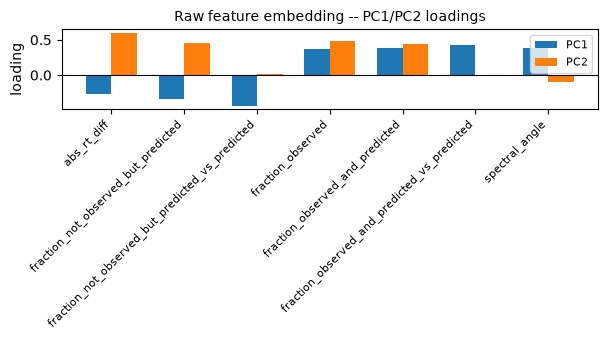

In [101]:
_ = plot_pca_loadings(raw_pca, FEATURES, title='Raw feature embedding -- PC1/PC2 loadings')

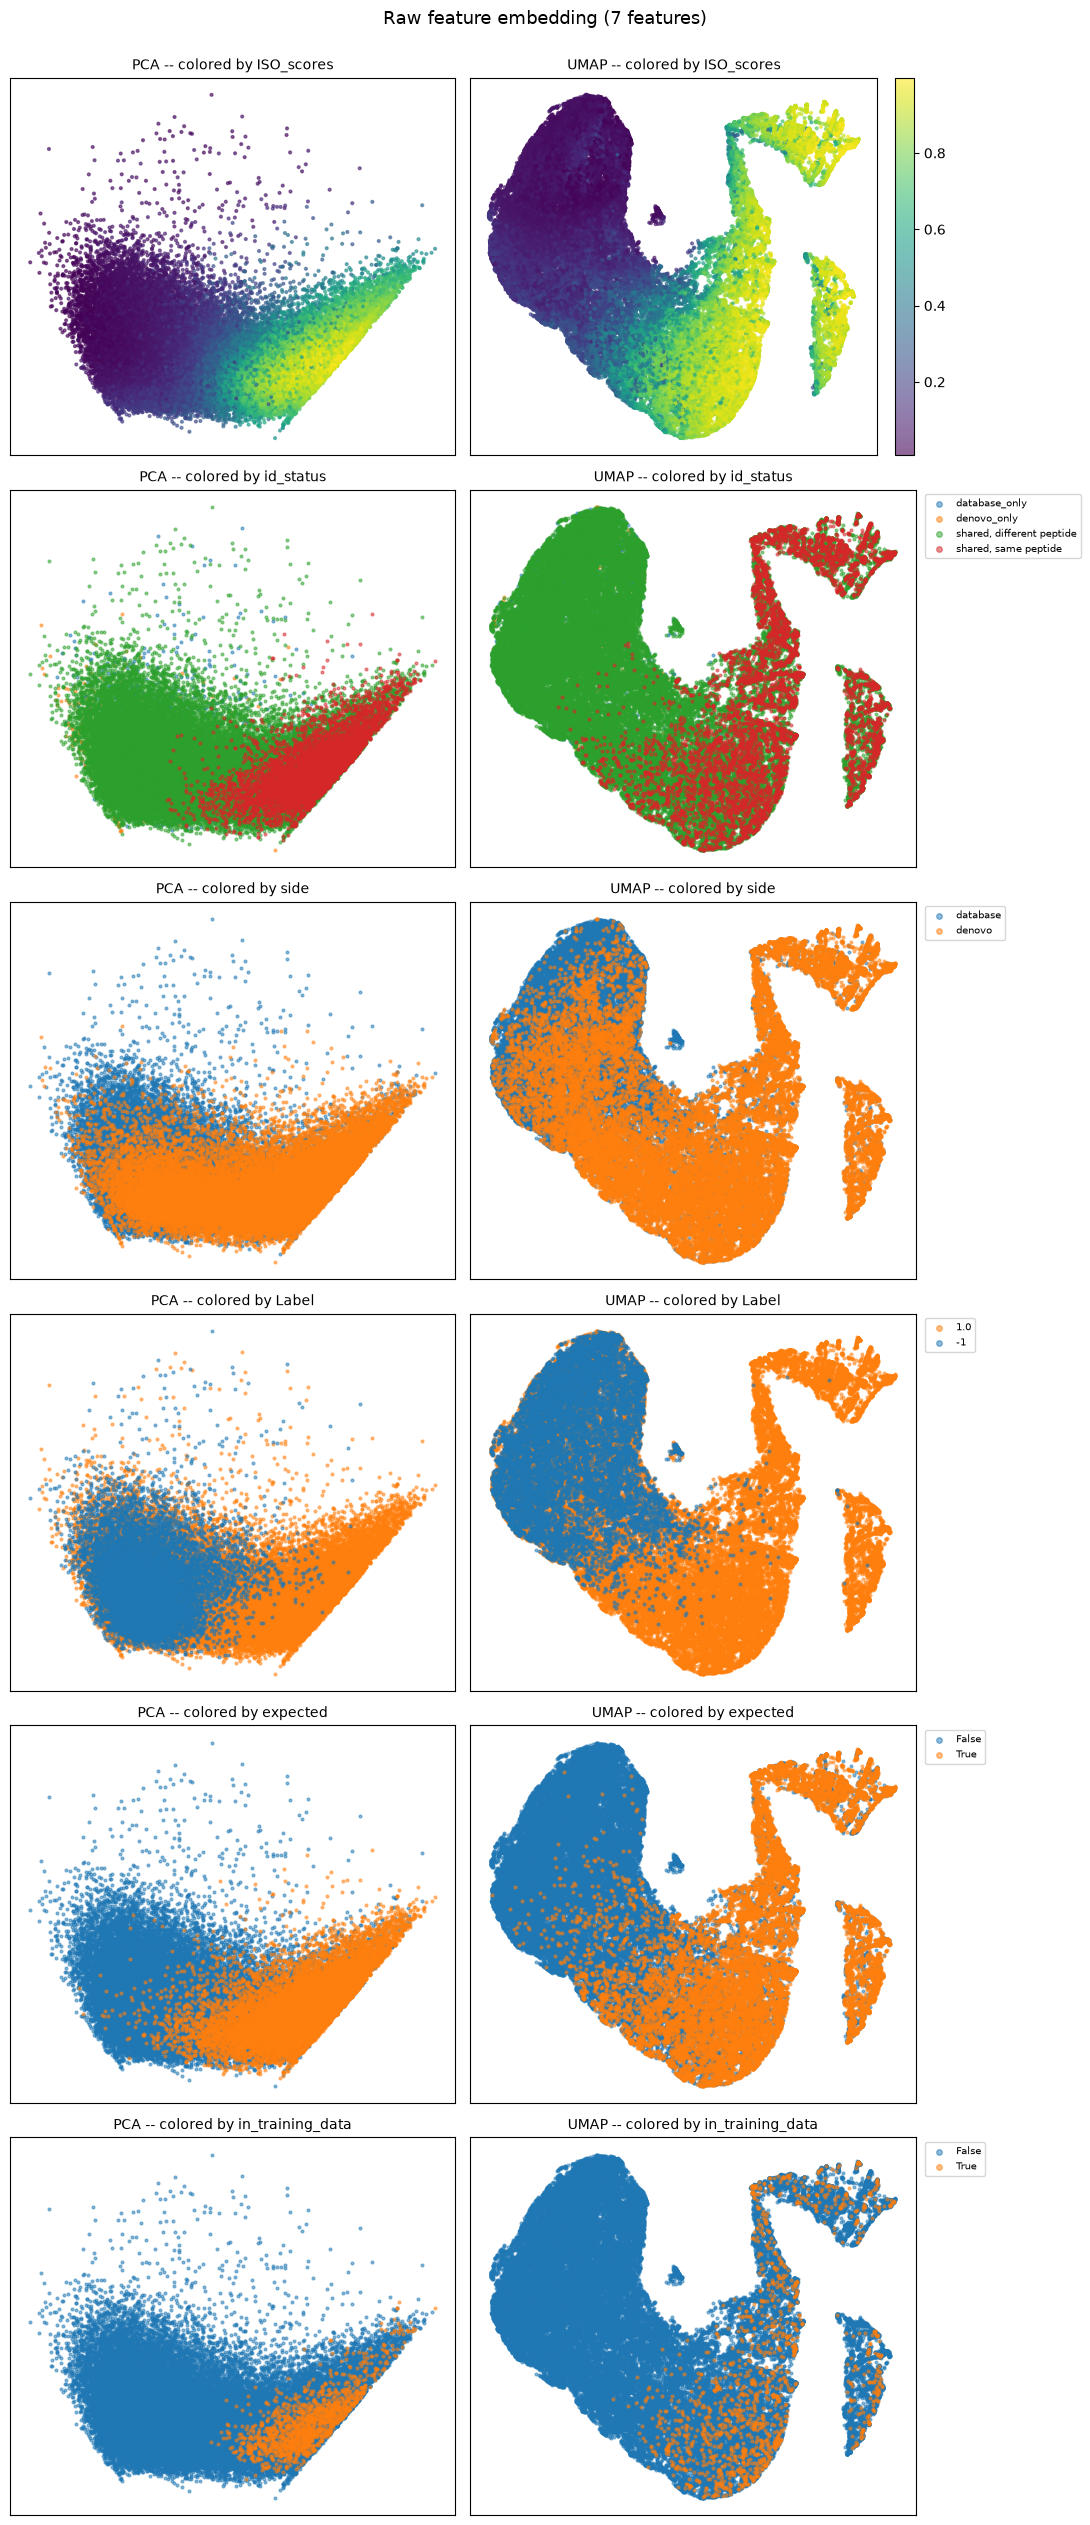

In [102]:
fig_raw = plot_embedding_grid(raw_coords, df, suptitle='Raw feature embedding (7 features)')

Below: the same PCA/UMAP coordinates, but with one row per feature instead of per status column -- colored by that feature's own raw (unstandardized) value, so you can read the embedding's structure back against each of the 7 input columns directly.

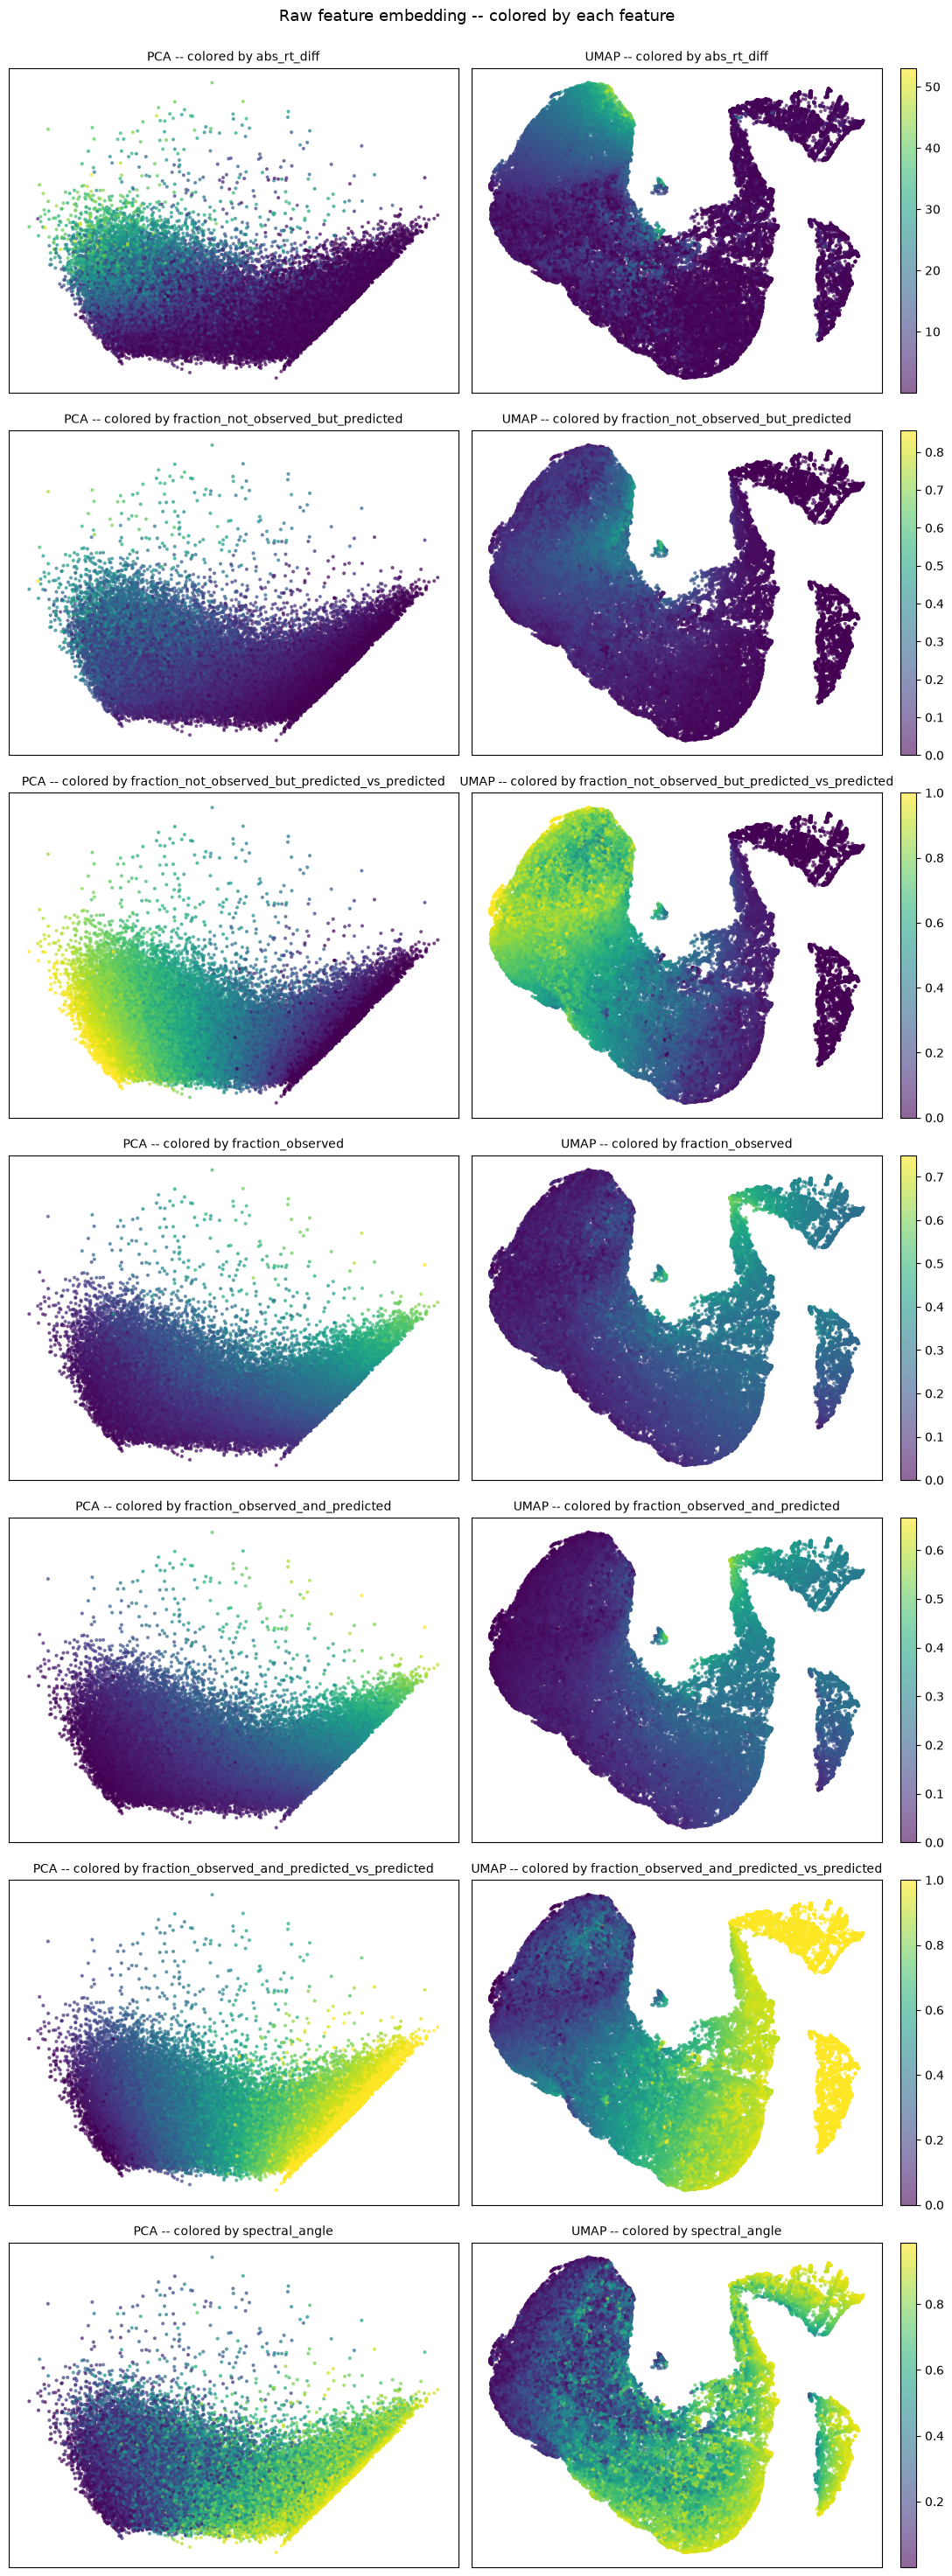

In [103]:
fig_raw_features = plot_feature_grid(
    raw_coords, {f: df[f] for f in FEATURES}, suptitle='Raw feature embedding -- colored by each feature'
)

## Plots -- engineered (direction-aware) features

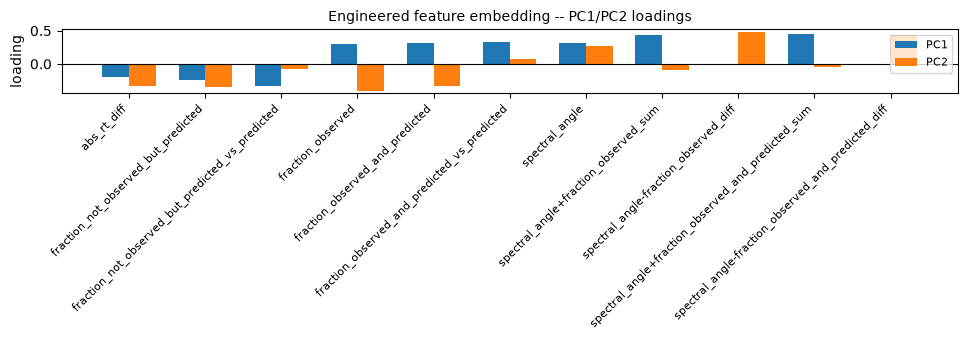

In [104]:
_ = plot_pca_loadings(
    engineered_pca, ENGINEERED_FEATURE_NAMES, title='Engineered feature embedding -- PC1/PC2 loadings'
)

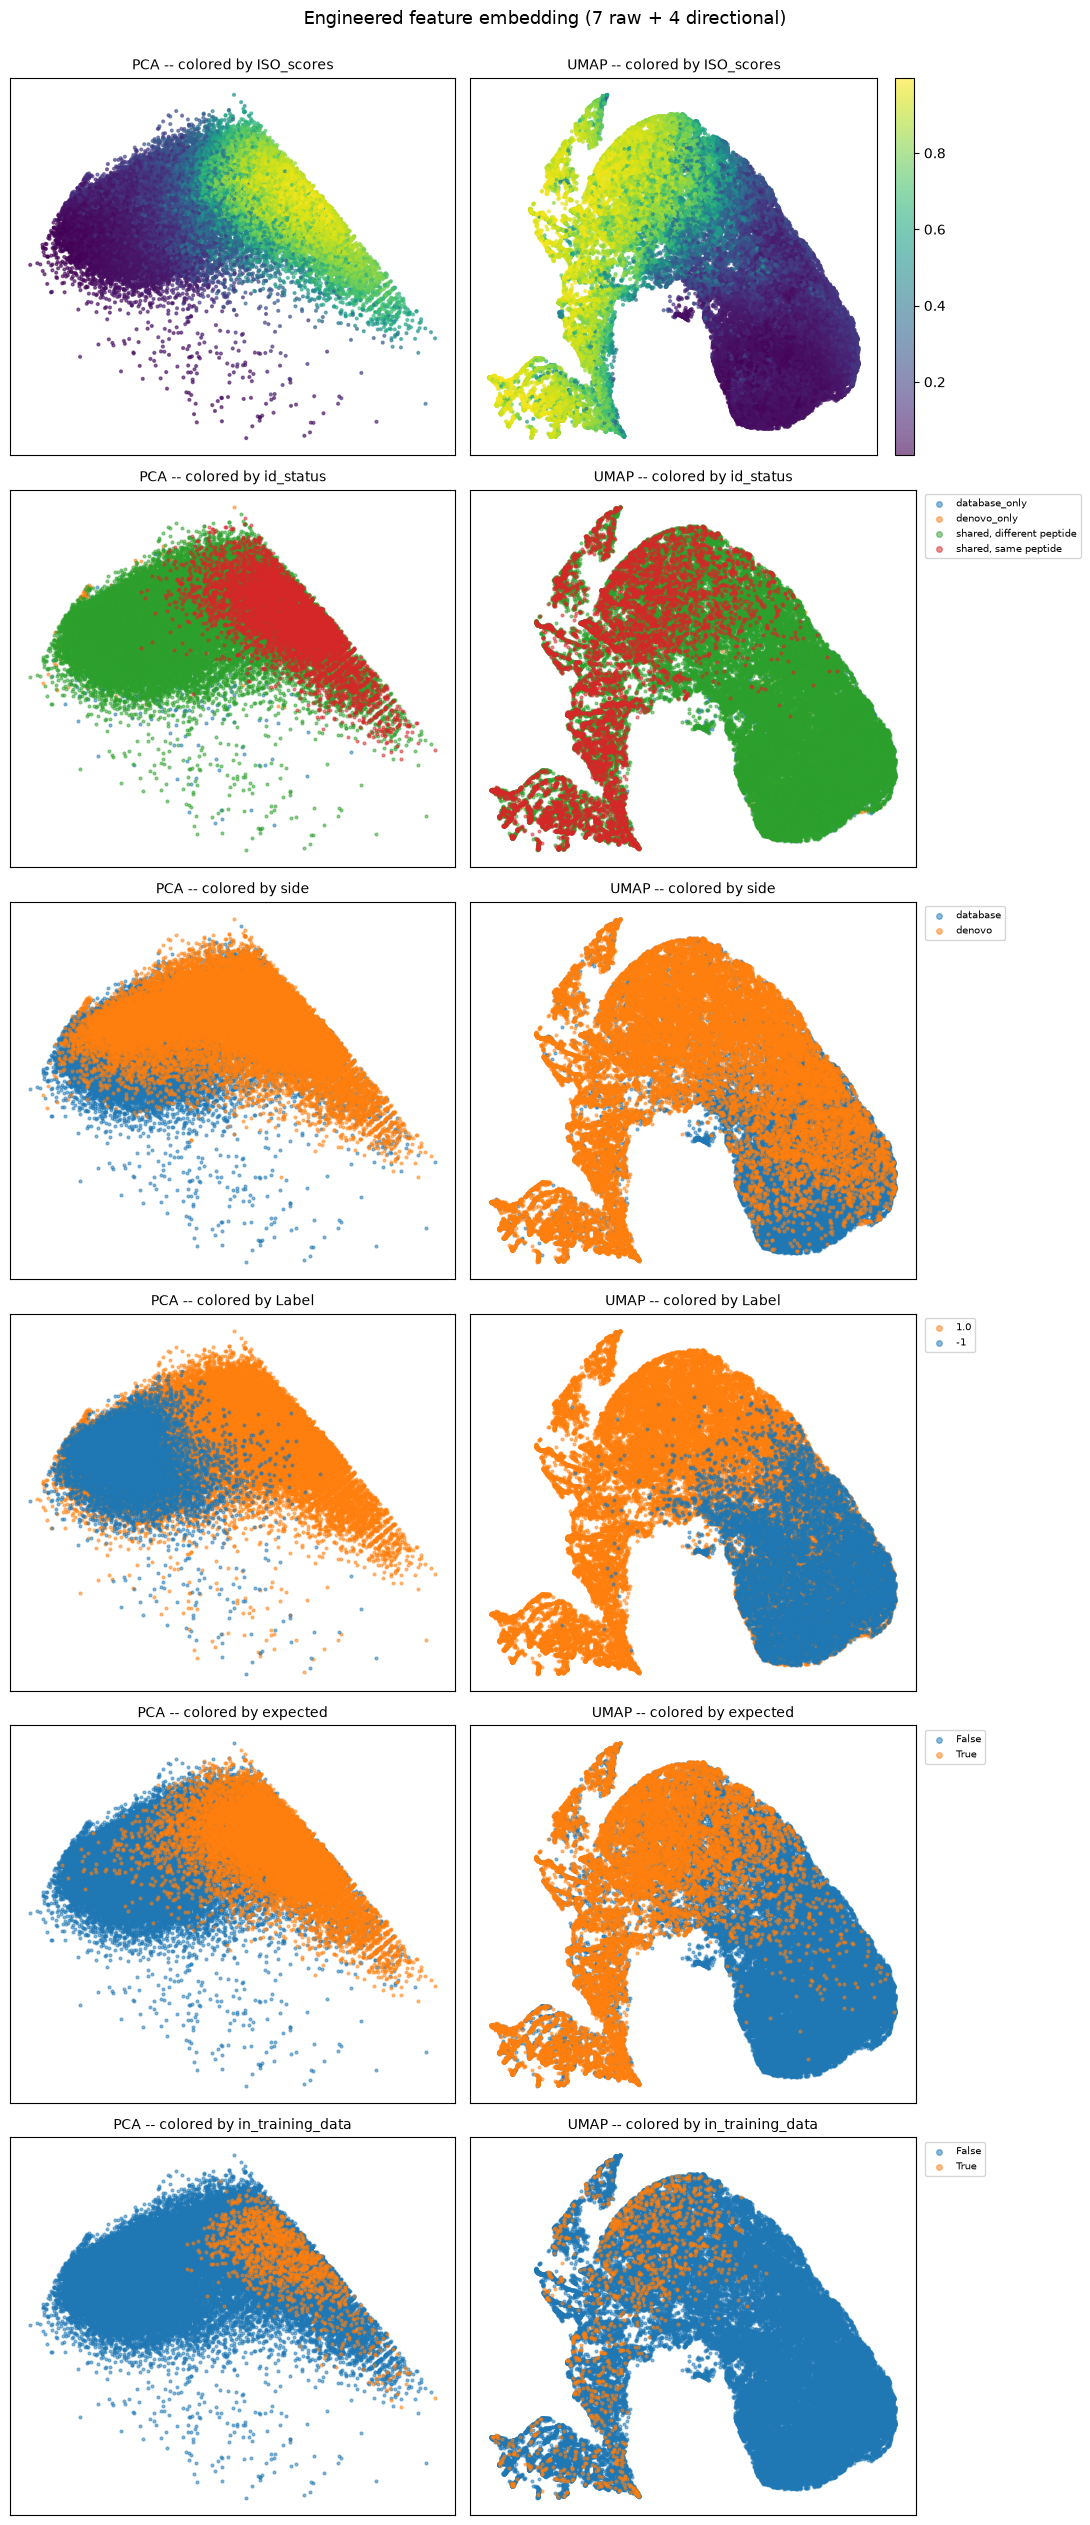

In [105]:
fig_engineered = plot_embedding_grid(
    engineered_coords, df, suptitle='Engineered feature embedding (7 raw + 4 directional)'
)

In [ ]:
fig_engineered_features = plot_feature_grid(
    engineered_coords,
    {name: X_engineered[:, i] for i, name in enumerate(ENGINEERED_FEATURE_NAMES)},
    suptitle='Engineered feature embedding -- colored by each feature',
)

## Correction factor -- local disagreement in UMAP embedding space

The raw isolation score treats every PSM the same way regardless of how well corroborated its identification is. This correction (`local_disagreement_correction` in `_shared.py`) is local and self-referential -- no separate "trusted reference" population needed: for each PSM, look at its `k` nearest neighbors in the raw-feature **UMAP embedding** (`raw_coords['UMAP']` computed above) and compare its own `ISO_scores` against those neighbors' own `ISO_scores` (their mean and std).

Corrects in **both directions**, always toward the local mean: a PSM scoring more than `z_threshold` local standard deviations *below* its neighbors' mean gets pushed **up**; one scoring more than `z_threshold` standard deviations *above* its neighbors' mean -- a spuriously high score sitting among otherwise low-scoring neighbors -- gets pulled **down** just as readily. Points within `z_threshold` of their local mean are left untouched, on purpose: agreement with the neighborhood (low or high) is more likely genuine, category-driven quality (see the `id_status`-split distribution above) than a scoring artifact.

In [ ]:
K_NEIGHBORS = 15
CORRECTION_STRENGTH = 0.5
Z_THRESHOLD = 1.0

corrected_zscore, local_mean, z = local_disagreement_correction(
    df['ISO_scores'].to_numpy(), raw_coords['UMAP'],
    k=K_NEIGHBORS, w=CORRECTION_STRENGTH, z_threshold=Z_THRESHOLD,
)
df['corrected_ISO_scores_zscore'] = corrected_zscore
flagged_up = z < -Z_THRESHOLD
flagged_down = z > Z_THRESHOLD

print(f'{flagged_up.sum():,} corrected up, {flagged_down.sum():,} corrected down '
      f'({100 * (flagged_up.sum() + flagged_down.sum()) / len(df):.2f}% total)')
print('corrected up -- id_status:')
print(df.loc[flagged_up, 'id_status'].value_counts())
print('corrected down -- id_status:')
print(df.loc[flagged_down, 'id_status'].value_counts())

10,431 corrected up, 9,192 corrected down (32.70% total)
corrected up -- id_status:
id_status
shared, different peptide    8832
shared, same peptide          821
database_only                 604
denovo_only                   174
Name: count, dtype: int64
corrected down -- id_status:
id_status
shared, different peptide    7619
shared, same peptide          750
database_only                 662
denovo_only                   161
Name: count, dtype: int64


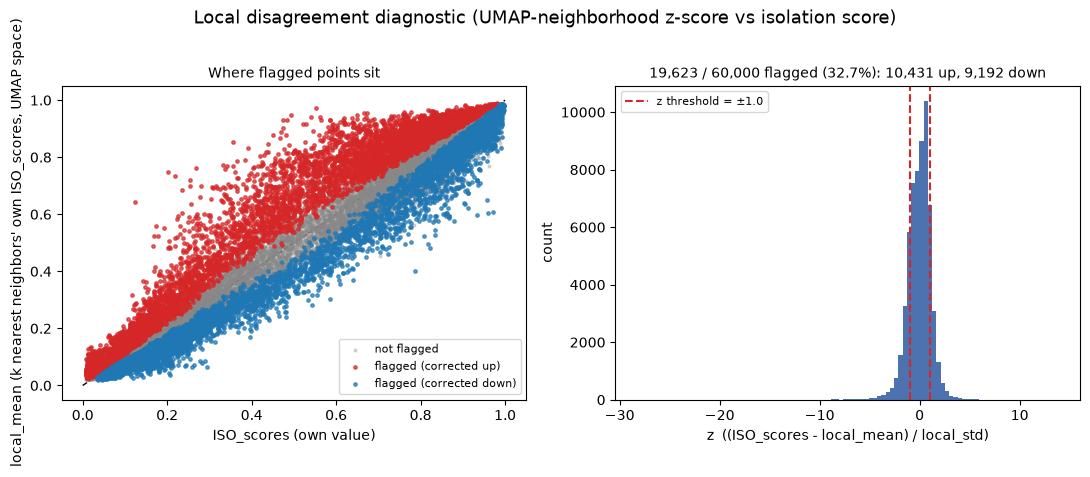

In [ ]:
fig_local_correction = plot_local_correction_diagnostic(
    df['ISO_scores'].to_numpy(), local_mean, z, Z_THRESHOLD,
    suptitle='Local disagreement diagnostic (UMAP-neighborhood z-score vs isolation score)',
)

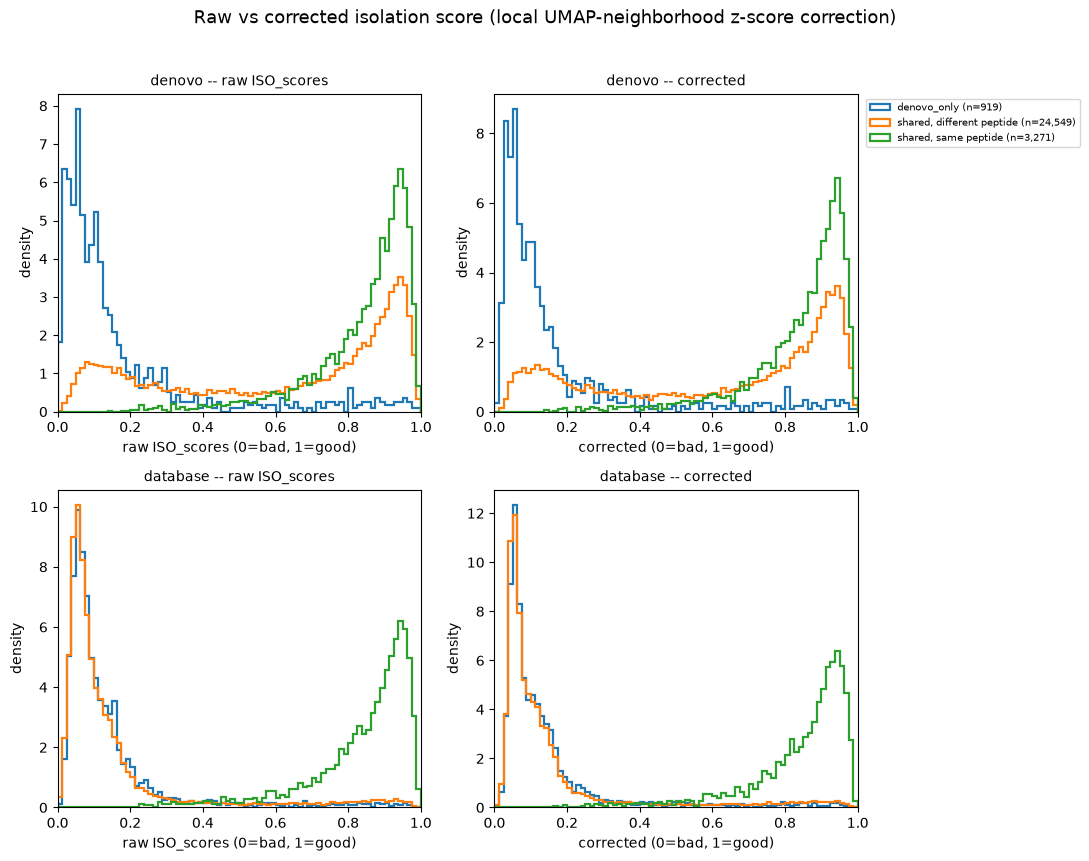

In [ ]:
fig_corrected_zscore = plot_score_correction(
    df, 'ISO_scores', 'corrected_ISO_scores_zscore',
    suptitle='Raw vs corrected isolation score (local UMAP-neighborhood z-score correction)',
)

## Correction factor -- local kernel regression in UMAP embedding space

A second, smoother take on the same idea (`local_regression_correction` in `_shared.py`). Instead of a hard k-NN mean/std and a threshold, each of the `k` nearest neighbors gets a Gaussian weight by distance (closer neighbors count more, bandwidth = the median neighbor distance by default), giving a Nadaraya-Watson-style local expectation `local_pred` for what this PSM's score "should" look like given its neighborhood.

**One-directional and threshold-free**, unlike the z-score correction above: every point with `local_pred > ISO_scores` gets pulled up by a fraction `w` of that gap, continuously (bigger gap -> bigger nudge, no on/off boundary) -- points already at or above their local expectation are untouched.

In [ ]:
REGRESSION_K_NEIGHBORS = 100
REGRESSION_STRENGTH = 0.5

corrected_regression, local_pred = local_regression_correction(
    df['ISO_scores'].to_numpy(), raw_coords['UMAP'], k=REGRESSION_K_NEIGHBORS, w=REGRESSION_STRENGTH,
)
df['corrected_ISO_scores_regression'] = corrected_regression
touched = local_pred > df['ISO_scores'].to_numpy()

print(f'{touched.sum():,} / {len(df):,} PSMs touched ({100 * touched.mean():.2f}%)')
print(df.loc[touched, 'id_status'].value_counts())

28,069 / 60,000 PSMs touched (46.78%)
id_status
shared, different peptide    23849
shared, same peptide          1943
database_only                 1803
denovo_only                    474
Name: count, dtype: int64


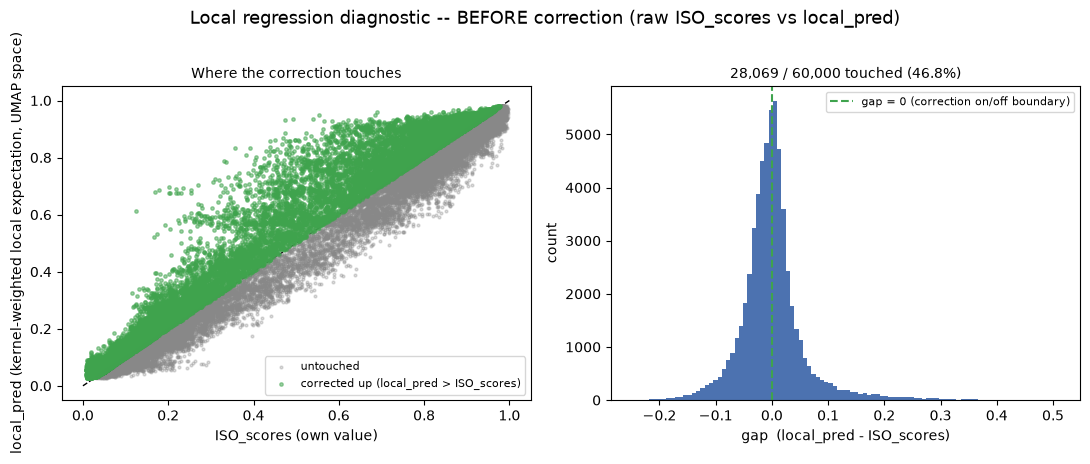

In [ ]:
fig_regression_correction = plot_regression_correction_diagnostic(
    df['ISO_scores'].to_numpy(), local_pred,
    suptitle='Local regression diagnostic -- BEFORE correction (raw ISO_scores vs local_pred)',
)

Re-running the same diagnostic on `corrected_ISO_scores_regression` itself -- feeding the *corrected* score back in as `if_scores` -- checks whether the correction actually closed the local gap it was reacting to. If it worked, this should show far fewer, smaller green points than the BEFORE plot above (most PSMs now sitting close to their own local neighborhood's expectation, gap ~ 0), not just the same gap shifted.

In [ ]:
corrected_regression_check, local_pred_after = local_regression_correction(
    df['corrected_ISO_scores_regression'].to_numpy(), raw_coords['UMAP'],
    k=REGRESSION_K_NEIGHBORS, w=REGRESSION_STRENGTH,
)
gap_before = local_pred - df['ISO_scores'].to_numpy()
gap_after = local_pred_after - df['corrected_ISO_scores_regression'].to_numpy()
print(f'mean positive gap before: {gap_before[gap_before > 0].mean():.4f}\n'
      f'mean positive gap after:  {gap_after[gap_after > 0].mean():.4f}\n'
      f'PSMs still touched after a second pass: {(gap_after > 0).sum():,} / {len(df):,} '
      f'(was {touched.sum():,})')

mean positive gap before: 0.0414
mean positive gap after:  0.0267
PSMs still touched after a second pass: 32,200 / 60,000 (was 28,069)


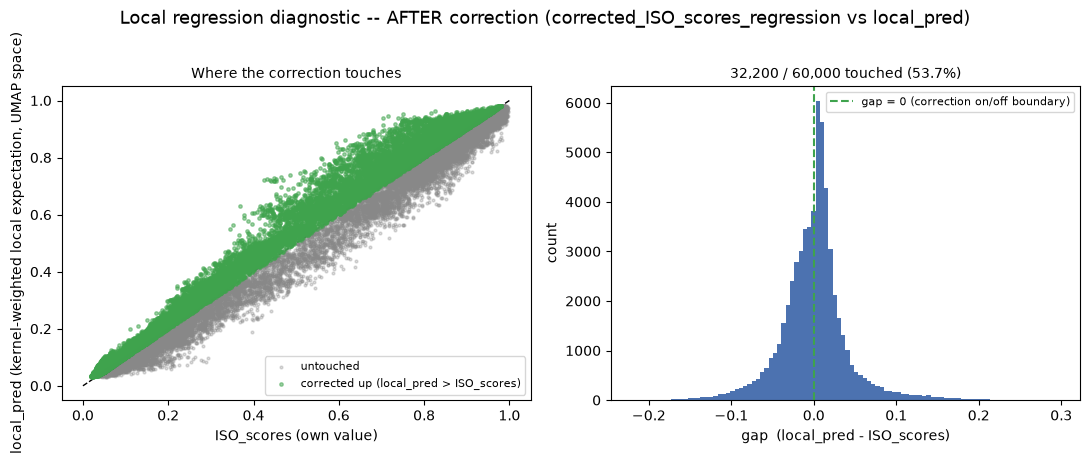

In [ ]:
fig_regression_correction_after = plot_regression_correction_diagnostic(
    df['corrected_ISO_scores_regression'].to_numpy(), local_pred_after,
    suptitle='Local regression diagnostic -- AFTER correction (corrected_ISO_scores_regression vs local_pred)',
)

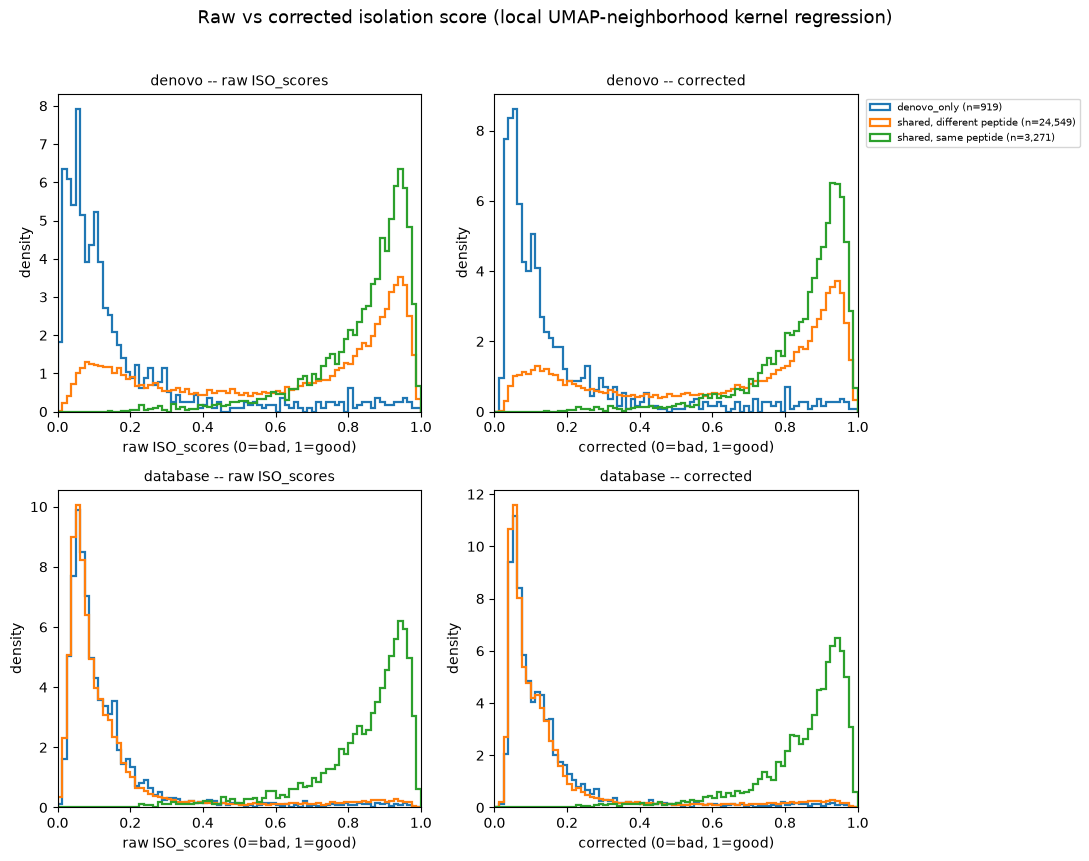

In [ ]:
fig_corrected_regression = plot_score_correction(
    df, 'ISO_scores', 'corrected_ISO_scores_regression',
    suptitle='Raw vs corrected isolation score (local UMAP-neighborhood kernel regression)',
)

## UMAP -- colored by corrected isolation score

Same `raw_coords['UMAP']` layout as the very first plot in this notebook, raw `ISO_scores` against both corrected variants side by side for a direct before/after read of where each correction moved things, and how the two methods differ.

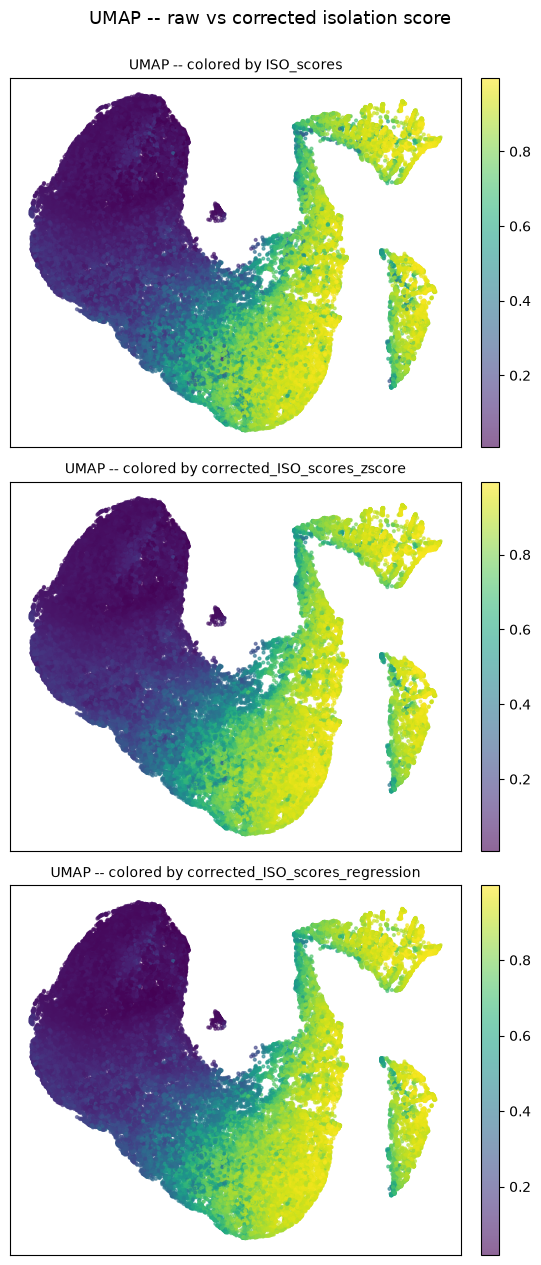

In [ ]:
fig_umap_corrected = plot_feature_grid(
    {'UMAP': raw_coords['UMAP']},
    {
        'ISO_scores': df['ISO_scores'].to_numpy(),
        'corrected_ISO_scores_zscore': df['corrected_ISO_scores_zscore'].to_numpy(),
        'corrected_ISO_scores_regression': df['corrected_ISO_scores_regression'].to_numpy(),
    },
    suptitle='UMAP -- raw vs corrected isolation score',
)

## AUC vs expected peptide -- corrected score vs Casanovo (this sample)

Same ground truth and metric as `../../../analysis/scripts/task08_auc_new_features.ipynb`: for every de novo-called scan, is the called sequence in its pool's expected-peptide list (`expected`, attached by `load_psm_sample`)? ROC AUC = how well a score ranks expected calls above not-expected ones.

This is the **sample-level** version (`side == 'denovo'` rows only, `~N_ROWS/2` scans, not the full 11.8M-scan corpus) -- a quick, cheap check within this notebook. For the authoritative full-scale numbers, see `../../../analysis/scripts/task08_auc_corrected_new_features.ipynb`.

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

denovo_df = df[df['side'] == 'denovo']
y = denovo_df['expected'].to_numpy()

SCORES = {
    'casanovo_score': 'Casanovo score',
    'ISO_scores': 'Isolation score (raw)',
    'corrected_ISO_scores_zscore': 'Isolation score (z-score corrected)',
    'corrected_ISO_scores_regression': 'Isolation score (regression corrected)',
}
auc = {c: float(roc_auc_score(y, denovo_df[c].to_numpy())) for c in SCORES}
for c, name in SCORES.items():
    print(f'{name:>36s}   AUC = {auc[c]:.4f}')

                      Casanovo score   AUC = 0.8703
               Isolation score (raw)   AUC = 0.8060
 Isolation score (z-score corrected)   AUC = 0.8047
Isolation score (regression corrected)   AUC = 0.8048


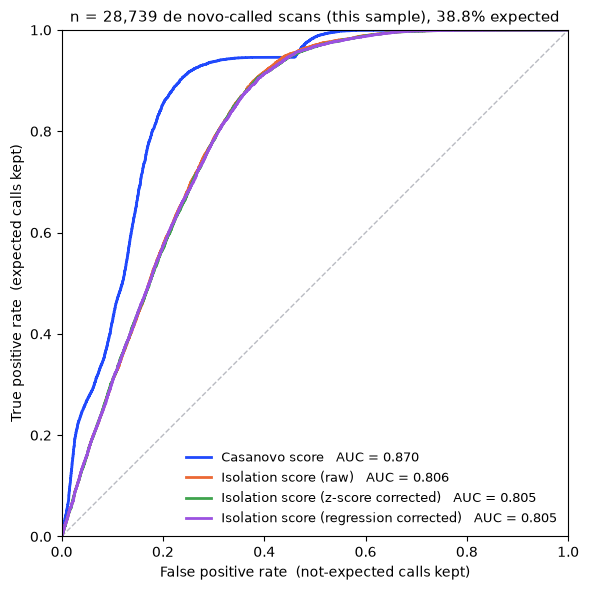

In [ ]:
COLORS = {
    'casanovo_score': '#2049FC',
    'ISO_scores': '#eb6834',
    'corrected_ISO_scores_zscore': '#3fa34d',
    'corrected_ISO_scores_regression': '#9b51e0',
}

fig_auc, ax = plt.subplots(figsize=(6, 6))
for c, name in SCORES.items():
    fpr, tpr, _ = roc_curve(y, denovo_df[c].to_numpy())
    ax.plot(fpr, tpr, color=COLORS[c], linewidth=2, label=f'{name}   AUC = {auc[c]:.3f}')

ax.plot([0, 1], [0, 1], color='#B9BBC2', linewidth=1, linestyle='--', zorder=0)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_xlabel('False positive rate  (not-expected calls kept)')
ax.set_ylabel('True positive rate  (expected calls kept)')
ax.set_title(f'n = {len(y):,} de novo-called scans (this sample), {100 * y.mean():.1f}% expected', fontsize=11)
ax.legend(loc='lower right', frameon=False, fontsize=9)
fig_auc.tight_layout()
plt.show()

## Notes

_Fill in after inspecting the plots: does the engineered variant separate `id_status` (in particular `shared, different peptide` vs `shared, same peptide`) or `Label` any more cleanly than the raw 7-feature embedding? Does the corrected score pull `shared, different peptide` further from `shared, same peptide` than raw `ISO_scores` does? Does the sample-level AUC above actually improve over raw `ISO_scores`, or is the correction just reshuffling scores within a rank tier? Compare against the isolation-forest leaf embedding in the companion notebook, and see `../../../analysis/scripts/task08_auc_corrected_new_features.ipynb` for the full-scale verdict._